In [1]:
import os
import numpy as np
from matplotlib import pyplot as plt

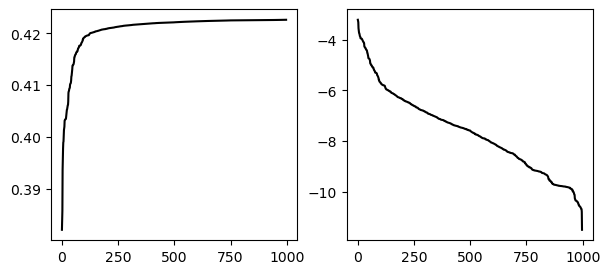

In [7]:
train_x = np.load("./train_X_8keV.npy")[1:].T
train_y = np.load("./train_Y_8keV.npy")[1:].T

xparams = [
    'defocus [A]',
    'layers',
    'thickness [A]'
]

sort_index = np.argsort(train_y)

x = train_x[:,sort_index]
y = train_y[sort_index]

EPSILON = 1e-5 # choose best according to plot

y_scaled = np.log(-y + y[-1] + EPSILON)

fig, ax = plt.subplots(1, 2, figsize=(7,3))
ax[0].plot(y, 'k')
ax[1].plot(y_scaled, 'k')
plt.show()

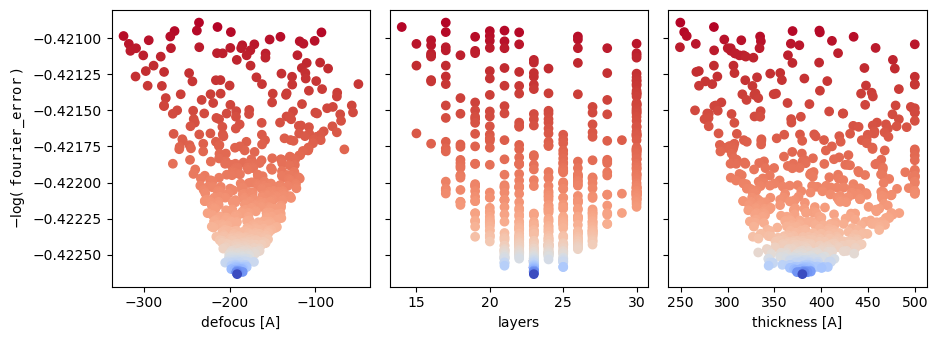

In [8]:
# Projection plots

cut = 200 # set to -1 to get all points

fig, axs = plt.subplots(1, len(x), figsize=(3*len(x)+0.5, 3.5), sharey=True)

for i, axi in enumerate(axs):
    axi.scatter(x[i][cut:], -y[cut:], c=y_scaled[cut:], cmap='coolwarm')
    axi.set_xlabel(xparams[i])

axs[0].set_ylabel('$- \\log (\ \\mathtt{fourier\_error}\ )$')

plt.tight_layout()
plt.show()

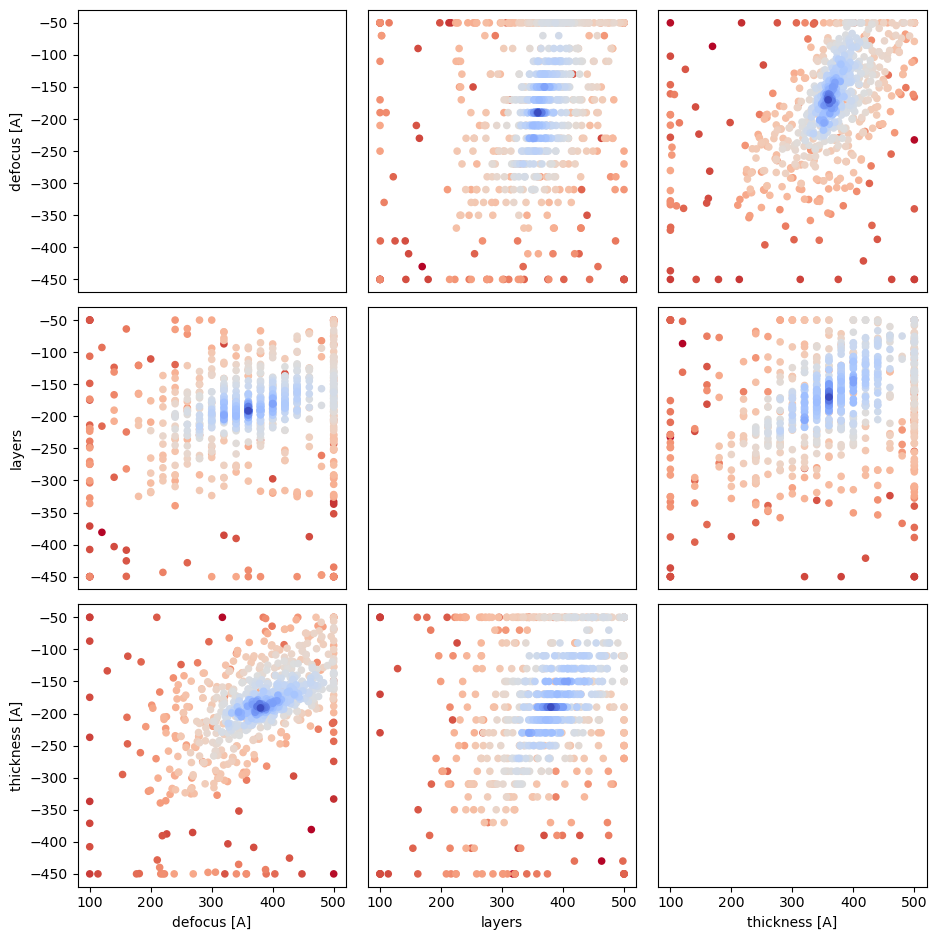

In [9]:
# Cross-correlation plots

fig, axs = plt.subplots(len(x), len(x), figsize=(3*len(x)+0.5, 3*len(x)+0.5))

for i, axi in enumerate(axs):
    for j, axij in enumerate(axi):
        axij.scatter(
            x[i], x[j],
            c = y_scaled, # color
            cmap = 'coolwarm',
            s = 20, # size
            alpha = 0 if i == j else 1 # make diagonal transparent
            )
        if i == len(x)-1:
            axij.set_xlabel(xparams[j])
        else:
            axij.set_xticks([])
        if j == 0:
            axij.set_ylabel(xparams[i])
        else:
            axij.set_yticks([])

plt.tight_layout()
plt.show()

